# Comparing cellcharter embedding UMAPs with scVI vs trVAE 
Generating plots used in thesis

In [1]:
import numpy as np
import anndata as ad
import scanpy as sc
import squidpy as sq
from pathlib import Path
import matplotlib.pyplot as plt
import os
import pandas as pd
import cellcharter as cc
import scvi

import logging
logger = logging.getLogger('pytorch_lightning.utilities.rank_zero')
logger.setLevel(logging.ERROR)

from lightning.pytorch import seed_everything
seed_everything(12345)

/exports/archive/hg-groep-spitali/Students/Caro/conda/envs/cellcharter/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/exports/archive/hg-groep-spitali/Students/Caro/conda/envs/cellcharter/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/exports/archive/hg-groep-spitali/Students/Caro/conda/envs/cellcharter/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_tex

12345

In [2]:
cd ../../data/IBM

/exports/archive/hg-groep-spitali/Students/Caro/data/IBM


/exports/archive/hg-groep-spitali/Students/Caro/conda/envs/cellcharter/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## 480 dataset

In [14]:
adata = sc.read_h5ad('cellcharter_clusters_anndata/480_dataset/Dimensionality_reduced_not_clustered/adata_480_fibnuc_trvae.h5ad')
adata

AnnData object with n_obs × n_vars = 154896 × 480
    obs: 'cell_ID', 'fov_labels', 'is_within_eroded', 'leiden', 'cluster', 'total_log1_counts', 'cell_type_annotation', 'condition', 'sample_id', 'sample_id_new', 'muscle_type', 'cell_type_annotation_clean', 'cell_type_annotation_fiber_subtypes', 'sample_condition'
    var: 'mean', 'std'
    uns: 'cell_type_annotation_colors', 'cluster_colors', 'fov_labels_colors', 'leiden', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_id_new_colors', 'spatialdata_attrs', 'umap'
    obsm: 'X_pca', 'X_scVI_condition', 'X_scVI_muscle', 'X_scVI_no_bc', 'X_scVI_samples', 'X_trVAE', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts_norm_log', 'counts_norm_log_scaled', 'raw'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'

In [15]:
sq.gr.spatial_neighbors(adata, library_key='sample_id_new', coord_type='generic',radius=[0,400], delaunay=True)

In [16]:
cc.gr.aggregate_neighbors(adata, n_layers=3, use_rep='X_trVAE', out_key='X_cc_trVAE', sample_key='sample_id_new')

cc.gr.aggregate_neighbors(adata, n_layers=3, use_rep='X_scVI_samples', out_key='X_cc_scVI', sample_key='sample_id_new')

100%|██████████| 6/6 [00:06<00:00,  1.16s/it]


In [17]:
sc.pp.neighbors(
    adata,
    use_rep="X_cc_trVAE",
    n_neighbors=15,
    random_state=1
)

sc.tl.umap(adata)

In [18]:
# Use better sample labels for plotting
adata.obs['sample_condition'] = adata.obs['sample_id_new'].copy()
adata.obs['sample_condition'] = adata.obs['sample_condition'].cat.add_categories(['Sample 1 - IBM', 'Sample 2 - IBM', 'Sample 3 - Healthy Control', 'Sample 4 - Healthy Control', 'Sample 5 - Healthy Control', 'Sample 6 - IBM'])

adata.obs.loc[adata.obs["sample_id_new"] == "sample1", "sample_condition"] = 'Sample 1 - IBM'
adata.obs.loc[adata.obs["sample_id_new"] == "sample2", "sample_condition"] = 'Sample 2 - IBM'
adata.obs.loc[adata.obs["sample_id_new"] == "sample3", "sample_condition"] = 'Sample 3 - Healthy Control'
adata.obs.loc[adata.obs["sample_id_new"] == "sample4", "sample_condition"] = 'Sample 4 - Healthy Control'
adata.obs.loc[adata.obs["sample_id_new"] == "sample5", "sample_condition"] = 'Sample 5 - Healthy Control'
adata.obs.loc[adata.obs["sample_id_new"] == "sample6", "sample_condition"] = 'Sample 6 - IBM'

adata.obs['sample_condition'] = adata.obs['sample_condition'].cat.remove_categories(['sample1', 'sample2','sample3','sample4','sample5','sample6'])


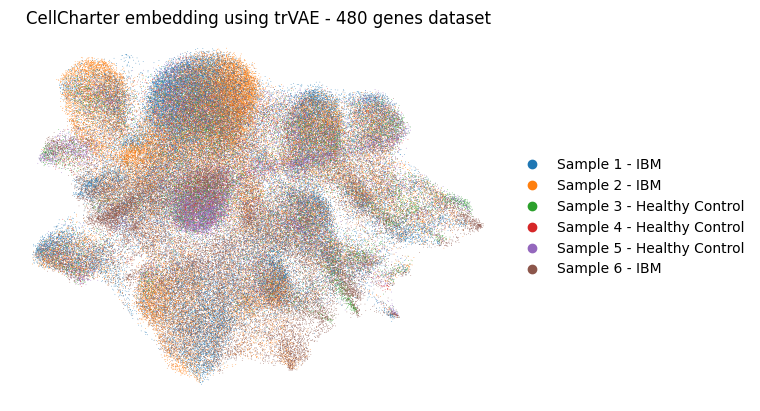

In [19]:
sc.pl.embedding(
        adata,
        "X_umap",
        color='sample_condition',
        title='CellCharter embedding using trVAE - 480 genes dataset',
        s=1,
        sort_order=False,
        frameon=False,
        save='trvae_480_fibnuc_umap.svg'
    )

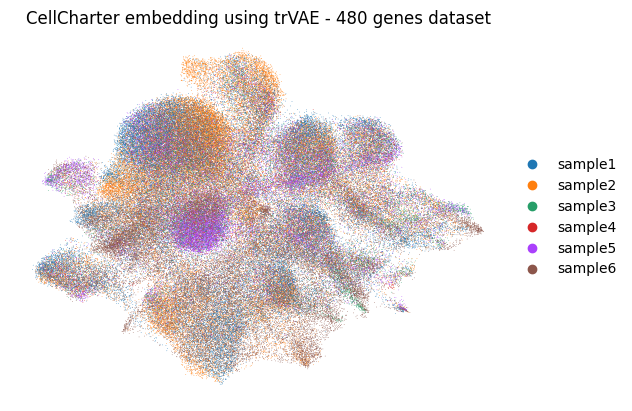

In [27]:
sc.pl.embedding(
        adata,
        "X_umap",
        color='sample_id_new',
        title='CellCharter embedding using trVAE - 480 genes dataset',
        s=1,
        sort_order=False,
        frameon=False,
    )

In [9]:
sc.pp.neighbors(
    adata,
    use_rep="X_cc_scVI",
    n_neighbors=15,
    random_state=1
)

sc.tl.umap(adata)

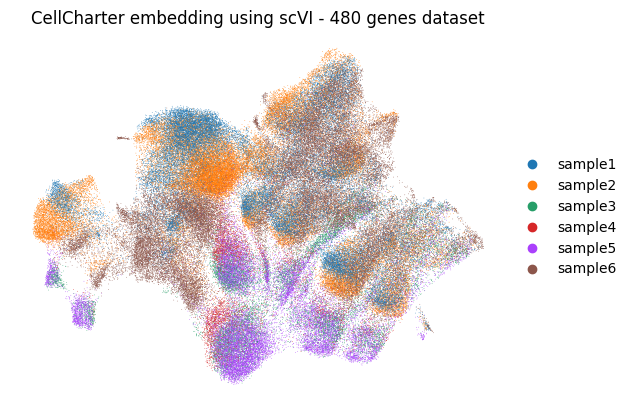

In [10]:
sc.pl.embedding(
        adata,
        "X_umap",
        color='sample_id_new',
        title='CellCharter embedding using scVI - 480 genes dataset',
        s=1,
        sort_order=False,
        frameon=False,
        save='scvi_480_fibnuc_umap.svg'
    )

In [37]:
sc.pp.neighbors(
    adata,
    use_rep="X_cc_scVI",
    n_neighbors=15,
    random_state=1
)

sc.tl.leiden(
    adata,
    resolution=0.7,
    key_added="spatial_clusters_scVI_0.7",
    random_state=1
)

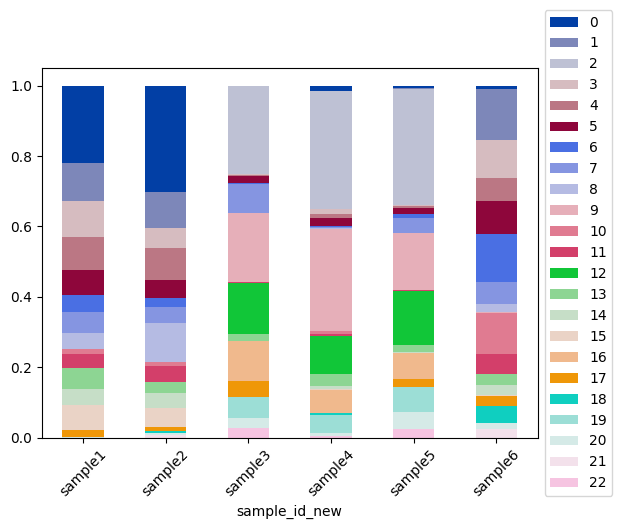

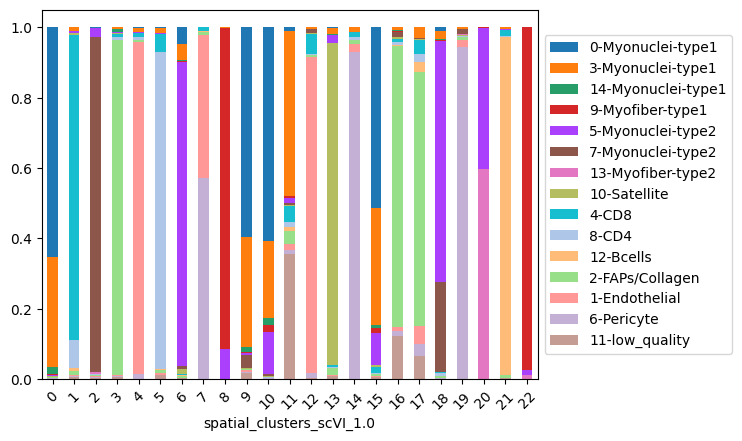

In [ ]:
cc.pl.proportion(adata, group_key='sample_id_new', label_key='spatial_clusters_scVI_1.0')

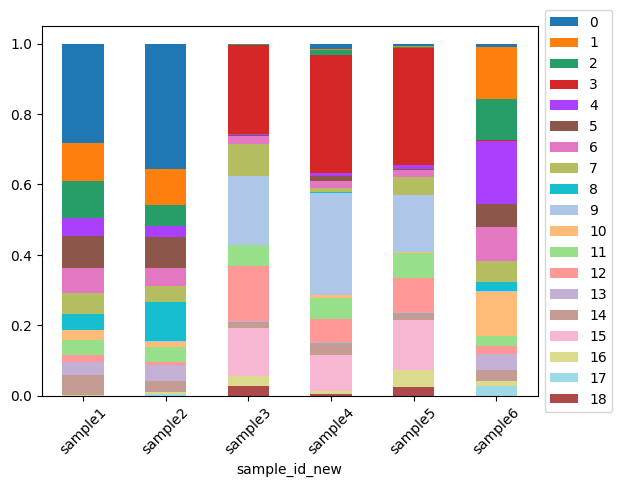

In [38]:
cc.pl.proportion(adata, group_key='sample_id_new', label_key='spatial_clusters_scVI_0.7')

Clear HC/IBM separation in spatial niches from scVI based cellcharter embedding

## 5000 dataset

In [32]:
adata = sc.read_h5ad('cellcharter_clusters_anndata/5000_dataset/Dimensionality_reduced_not_clustered/adata_5000_fibnuc_trvae.h5ad')
adata

AnnData object with n_obs × n_vars = 161889 × 5571
    obs: 'cell_ID', 'fov_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_2_genes', 'pct_counts_in_top_5_genes', 'n_counts', 'shapeSize', 'leiden_pcs10_res0.5', 'sample_id', 'condition', 'muscle_type', 'sample_id_new', 'cell_type_annotation'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'mean', 'std'
    uns: 'leiden_pcs10_res0.5', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'spatialdata_attrs', 'umap'
    obsm: 'X_pca', 'X_trVAE', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'raw_counts'
    obsp: 'connectivities', 'distances'

In [11]:
sq.gr.spatial_neighbors(adata, library_key='sample_id_new', coord_type='generic',radius=[0,400], delaunay=True)

In [12]:
cc.gr.aggregate_neighbors(adata, n_layers=3, use_rep='X_trVAE', out_key='X_cc_trVAE', sample_key='sample_id_new')

100%|██████████| 6/6 [00:04<00:00,  1.31it/s]


In [13]:
sc.pp.neighbors(
    adata,
    use_rep="X_cc_trVAE",
    n_neighbors=15,
    random_state=1
)

sc.tl.umap(adata)

In [14]:
# Use better sample labels for plotting
adata.obs['sample_condition'] = adata.obs['sample_id_new'].copy()
adata.obs['sample_condition'] = adata.obs['sample_condition'].cat.add_categories(['Sample 1 - IBM', 'Sample 2 - IBM', 'Sample 3 - Healthy Control', 'Sample 4 - Healthy Control', 'Sample 5 - Healthy Control', 'Sample 6 - IBM'])

adata.obs.loc[adata.obs["sample_id_new"] == "sample1", "sample_condition"] = 'Sample 1 - IBM'
adata.obs.loc[adata.obs["sample_id_new"] == "sample2", "sample_condition"] = 'Sample 2 - IBM'
adata.obs.loc[adata.obs["sample_id_new"] == "sample3", "sample_condition"] = 'Sample 3 - Healthy Control'
adata.obs.loc[adata.obs["sample_id_new"] == "sample4", "sample_condition"] = 'Sample 4 - Healthy Control'
adata.obs.loc[adata.obs["sample_id_new"] == "sample5", "sample_condition"] = 'Sample 5 - Healthy Control'
adata.obs.loc[adata.obs["sample_id_new"] == "sample6", "sample_condition"] = 'Sample 6 - IBM'

adata.obs['sample_condition'] = adata.obs['sample_condition'].cat.remove_categories(['sample1', 'sample2','sample3','sample4','sample5','sample6'])


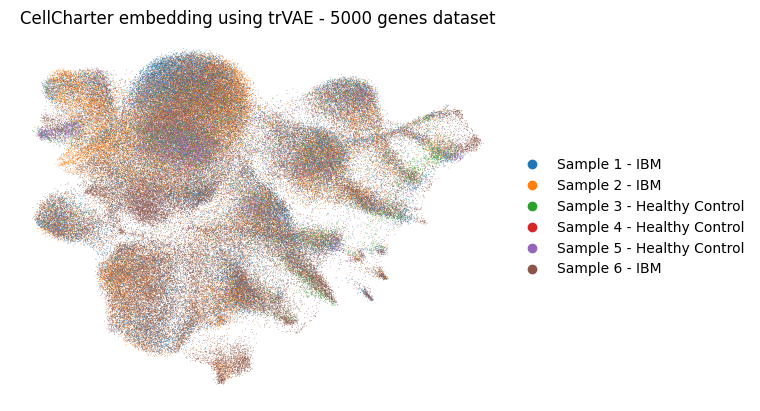

In [15]:
sc.pl.embedding(
        adata,
        "X_umap",
        color='sample_condition',
        title='CellCharter embedding using trVAE - 5000 genes dataset',
        s=1,
        sort_order=False,
        frameon=False,
    )

### scVI dimensionality reduction with sample batch correction

In [33]:
scvi.settings.seed = 12345
scvi.settings.num_threads = 2

#setup model
scvi.model.SCVI.setup_anndata(
    adata, 
    layer="raw_counts",
    batch_key='sample_id_new'
)

LOAD_MODEL = True

# create scVI model with 10 latent embedding size
model_samples = scvi.model.SCVI(adata)

model_samples.train(early_stopping=True, enable_progress_bar=True, max_epochs=15)

[rank: 0] Seed set to 12345
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


Epoch 15/15: 100%|██████████| 15/15 [03:20<00:00, 13.15s/it, v_num=1, train_loss_step=1.57e+3, train_loss_epoch=1.25e+3]

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 15/15: 100%|██████████| 15/15 [03:20<00:00, 13.35s/it, v_num=1, train_loss_step=1.57e+3, train_loss_epoch=1.25e+3]


In [34]:
adata.obsm['X_scVI'] = model_samples.get_latent_representation(adata).astype(np.float32)

In [35]:
sq.gr.spatial_neighbors(adata, library_key='sample_id_new', coord_type='generic',radius=[0,400], delaunay=True)

In [36]:
cc.gr.aggregate_neighbors(adata, n_layers=3, use_rep='X_scVI', out_key='X_cc_scVI', sample_key='sample_id_new')

100%|██████████| 6/6 [00:04<00:00,  1.39it/s]


In [37]:
sc.pp.neighbors(
    adata,
    use_rep="X_cc_scVI",
    n_neighbors=15,
    random_state=1
)

sc.tl.umap(adata)

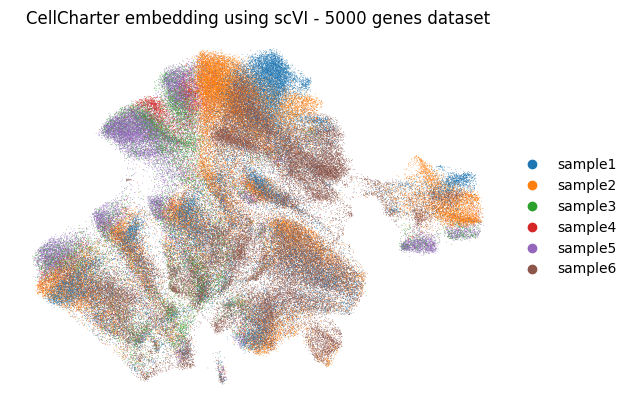

In [38]:
sc.pl.embedding(
        adata,
        "X_umap",
        color='sample_id_new',
        title='CellCharter embedding using scVI - 5000 genes dataset',
        s=1,
        sort_order=False,
        frameon=False,
    )